# Evaluation-first fine-tuning of Ministral 3 on Apple Silicon

A tiny bottling-line simulator with known physics, a mechanical scorer on top
of it, and Ministral 3 3B (4-bit) running locally through MLX. The point is a
loop: when a diagnosis task has verifiable answers, the evaluation environment
and the training environment are the same object, so the station that measures
the model can also feed it. On this toy, that loop takes the model from a 13
percent naive baseline to 87 percent, using nothing but what the station
itself produces.

Everything is in this one notebook: the simulator, the scorer, the model
harness, the gold-data builder, the SFT loop, and every result of the full
study with its figures. You will run the measuring side live (about ten
minutes on an M-series Mac); the training cells are guarded by a flag you can
flip (one SFT epoch is about four hours). The repo behind it is
[Lee-Gihun/minifab](https://github.com/Lee-Gihun/minifab).

**Requirements**: Apple Silicon. Tested with
`pip install mlx-lm==0.31.3 mistral-common==1.11.5`

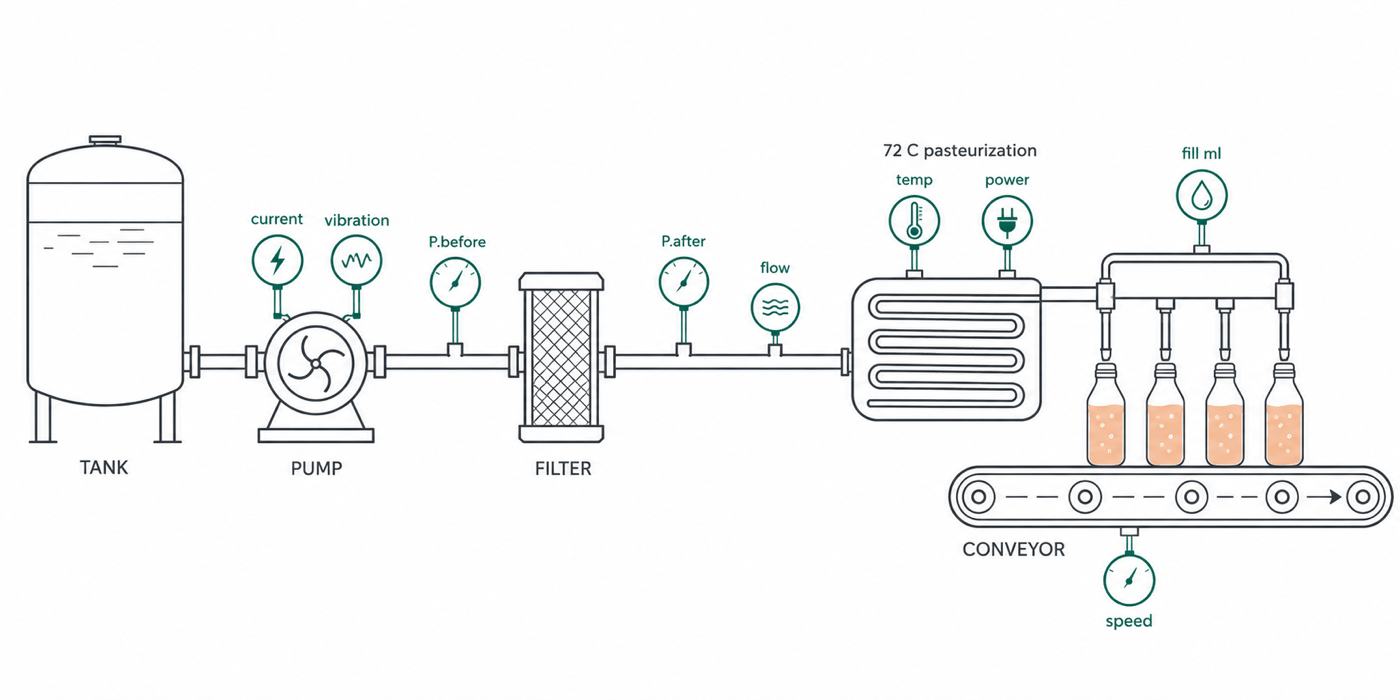

The design in three commitments:

- **Verifiable core.** The simulator injects every fault it knows, so scoring
  never rests on opinion. Faults are arranged in confusable pairs, so the task
  is causal reading, not value lookup.
- **One contract.** The scorer below is the single definition of success:
  evaluation reports it, and the RL phase later uses it verbatim as the
  reward. No separate reward engineering.
- **Observability honesty.** Onset is scored against the first minute a fault
  was mechanically visible above sensor noise, not the latent start, so a
  constant-guess strategy cannot collect the credit.

The two confusions that carry the difficulty: a clogging filter and a wearing
pump look identical from downstream (only the pressure pair around the filter
and bearing vibration separate them), and a drifting temperature sensor that
the thermostat believes, which genuinely overheats the line while the panel
reads a normal 72.

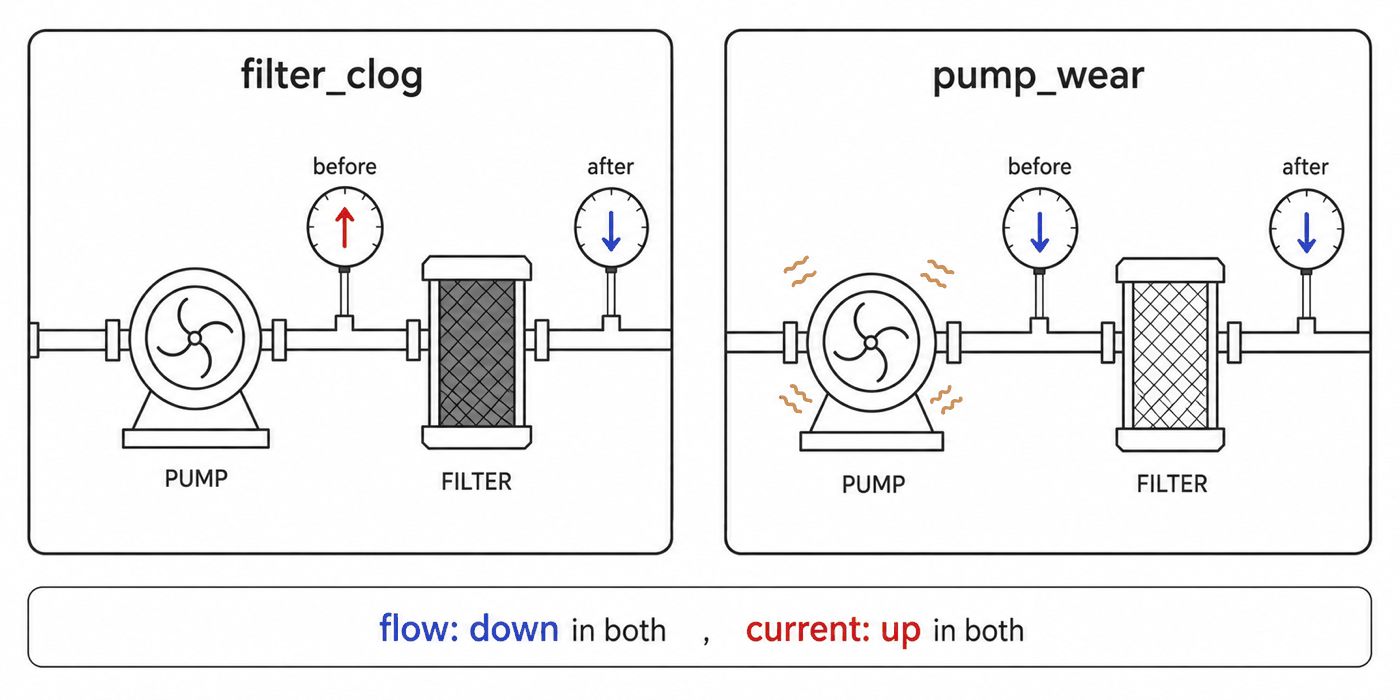

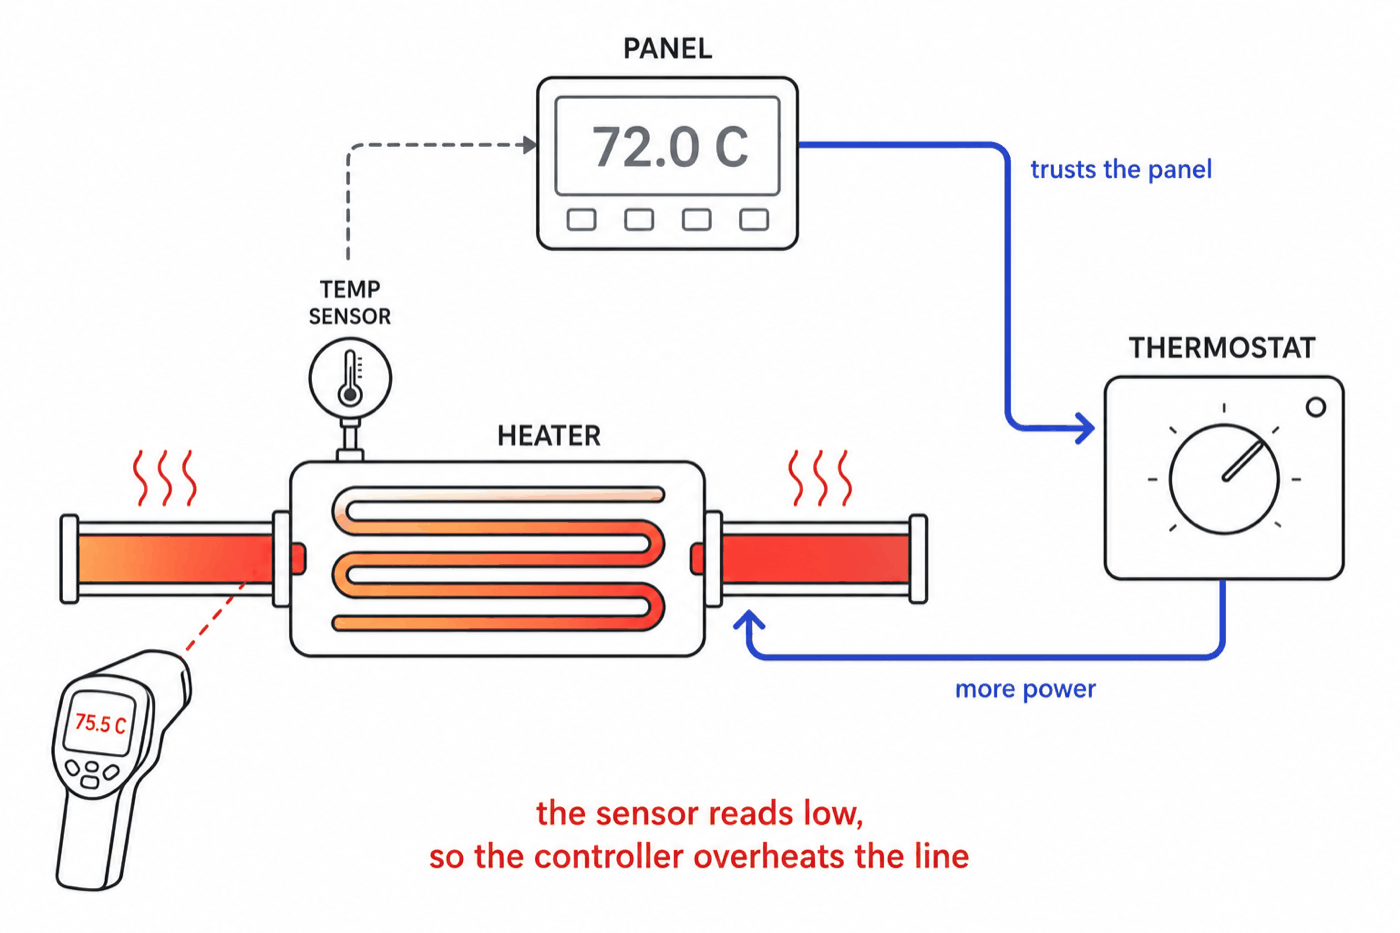

### The simulator

Hidden causal state, noisy sensors, eight faults, full ground truth per
episode. Three places worth actually reading as you skim: `level()` (gradual
faults ramp over 45 minutes, so a fault exists before it is visible), the
thermostat line in `step()` (it acts on the *measured* temperature, which is
what turns a lying sensor into real overheating), and the `first_detect`
block (the first minute any noiseless sensor leaves its 3-sigma band, which
is what onset is scored against).

In [1]:
"""Bottling line simulator: hidden causal state, noisy observable surfaces.

The line: tank -> pump -> filter -> heater (pasteurization) -> filler nozzles -> conveyor.
Physics is deliberately simple but causal: faults perturb hidden component state,
effects propagate with lags, sensors add noise, and the heater thermostat reacts
to the *measured* temperature, so a lying sensor genuinely misleads the line,
not just the reader.

Every episode carries full ground truth for oracle scoring. Stdlib only,
deterministic per seed.
"""
import json
import random

DUR_DEFAULT = 120  # minutes per episode


def clamp(x, lo, hi):
    return max(lo, min(hi, x))


class Line:
    def __init__(self, domain, fault, seed, dur=DUR_DEFAULT):
        self.d = domain
        self.fault = fault
        self.dur = dur
        self.rng = random.Random(seed)
        self.strength = self.rng.uniform(0.75, 1.0)
        if fault is None:
            self.onset = None
        elif fault == "recipe_misconfig":
            self.onset = 60  # loaded at shift change, where a human would do it
        else:
            self.onset = self.rng.randint(25, 70)

        # hidden component state
        self.clog = 0.0      # filter blockage fraction
        self.wear = 0.0      # pump bearing wear fraction
        self.heff = 1.0      # heater efficiency
        self.toff = 0.0      # temp sensor offset (C), the lying instrument
        self.leak = 0.0      # tank outlet valve leak fraction
        self.nozzle3 = 0.0   # nozzle 3 blockage fraction
        self.fill_target = 500.0
        self.temp_target = 72.0
        self.power = 3.0
        self.real_temp = 72.0
        self.slip_left = 0
        self.recipe_event_pending = fault == "recipe_misconfig"

        self.fills = []      # (nozzle, ml) recent bottles
        self.bottle_idx = 0
        self.first_detect = None  # first minute any noiseless sensor deviates >= 3 sigma

    def level(self, t):
        if self.fault is None or t < self.onset:
            return 0.0
        profile = self.d["faults"][self.fault]["profile"]
        if profile == "gradual":
            return min(1.0, (t - self.onset) / 45.0) * self.strength
        return self.strength  # step / intermittent

    def step(self, t):
        rng = self.rng
        lvl = self.level(t)
        events = []

        if self.fault == "filter_clog":
            self.clog = 0.6 * lvl
        elif self.fault == "pump_wear":
            self.wear = 0.6 * lvl
        elif self.fault == "heater_degradation":
            self.heff = 1.0 - 0.13 * lvl
        elif self.fault == "temp_sensor_drift":
            self.toff = -3.5 * lvl
        elif self.fault == "valve_leak":
            self.leak = 0.5 * lvl
        elif self.fault == "nozzle_clog":
            self.nozzle3 = 0.18 * lvl
        elif self.fault == "recipe_misconfig" and lvl > 0 and self.recipe_event_pending:
            self.fill_target = 482.0
            self.recipe_event_pending = False
            events.append("controller: recipe 'BATCH-B' loaded by operator")
        elif self.fault == "belt_slip" and lvl > 0:
            if self.slip_left == 0 and rng.random() < 0.12:
                self.slip_left = rng.randint(3, 6)

        # pump / filter / valve physics
        pressure_before = 2.4 + 0.50 * self.clog - 0.50 * self.wear - 0.15 * self.leak
        pressure_after = 2.0 - 0.45 * self.clog - 0.45 * self.wear - 0.10 * self.leak
        flow = 10.0 - 3.2 * self.clog - 2.6 * self.wear - 1.6 * self.leak
        pump_current = 2.0 + 0.35 * self.clog + 0.40 * self.wear
        vibration = 0.8 + 1.10 * self.wear

        # heater: thermostat acts on MEASURED temp
        equilib = 60.0 + 4.0 * self.power * self.heff
        self.real_temp += 0.35 * (equilib - self.real_temp)
        measured_temp = self.real_temp + self.toff
        self.power = clamp(self.power + 0.12 * (self.temp_target - measured_temp), 2.0, 4.5)

        # conveyor
        slipping = self.slip_left > 0
        if slipping:
            self.slip_left -= 1
            speed = 24.0 + rng.uniform(-1.5, 1.5)
            if rng.random() < 0.25:
                events.append("operator note: conveyor briefly sluggish, bottles bunching")
        else:
            speed = 30.0

        # bottles filled this minute
        fill_factor = clamp(flow / 10.0, 0.85, 1.02)
        n_bottles = int(round(speed))
        for _ in range(n_bottles):
            nozzle = self.bottle_idx % 4
            ml = self.fill_target * (0.9 + 0.1 * fill_factor)
            if nozzle == 2:
                ml *= 1.0 - self.nozzle3
            if slipping:
                ml *= 1.025  # bottles linger under the nozzle
            ml += rng.gauss(0, 1.5 + 2.5 * self.leak)
            self.fills.append((nozzle, ml))
            self.bottle_idx += 1
        self.fills = self.fills[-400:]

        # occasional fault-scented operator observations
        if self.fault == "valve_leak" and lvl > 0.4 and rng.random() < 0.02:
            events.append("operator note: small puddle near tank outlet")

        # observable onset: the latent fault exists from self.onset, but scoring must
        # anchor to the first minute a sensor could actually show it (>= 3 sigma,
        # noiseless). Gradual faults ramp from zero; punishing a reader for not
        # seeing an invisible fault would reward constant-guessing instead.
        if self.fault and self.onset is not None and t >= self.onset and self.first_detect is None:
            mean_fill = self.fill_target * (0.9 + 0.1 * fill_factor) * (1 - self.nozzle3 / 4)
            if slipping:
                mean_fill *= 1.025
            noiseless = {"pump_current": pump_current, "pressure_before": pressure_before,
                         "pressure_after": pressure_after, "flow": flow,
                         "heater_temp": measured_temp, "heater_power": self.power,
                         "fill_volume": mean_fill, "conveyor_speed": speed,
                         "pump_vibration": vibration}
            for s, v in noiseless.items():
                if abs(v - self.d["sensors"][s]["base"]) >= 3 * self.d["sensors"][s]["noise"]:
                    self.first_detect = t
                    break

        def noise(s):
            return rng.gauss(0, self.d["sensors"][s]["noise"])
        sensors = {
            "pump_current": pump_current + noise("pump_current"),
            "pressure_before": pressure_before + noise("pressure_before"),
            "pressure_after": pressure_after + noise("pressure_after"),
            "flow": flow + noise("flow"),
            "heater_temp": measured_temp + noise("heater_temp"),
            "heater_power": self.power + noise("heater_power"),
            "fill_volume": (sum(m for _, m in self.fills[-12:]) / max(1, len(self.fills[-12:]))),
            "conveyor_speed": speed + noise("conveyor_speed"),
            "pump_vibration": vibration + noise("pump_vibration"),
        }
        return sensors, events


def render_episode(domain, fault, seed, dur=DUR_DEFAULT):
    line = Line(domain, fault, seed, dur)
    rng = random.Random(seed + 7919)
    out = []
    out.append("=== LINE-1 shift log | spec: fill 500 ml +/- 5 | pasteurize at 72 C ===")
    out.append("baselines: pump 2.00 A | P.before 2.40 bar | P.after 2.00 bar | "
               "flow 10.0 L/min | heater 72.0 C @ 3.0 kW | fill 500 ml | conveyor 30/min | vib 0.80 mm/s")

    # one early, one late: the late check is guaranteed past any fault's ramp,
    # so the drift/degradation discriminator is always present in principle
    manual_checks = sorted([rng.randint(30, 65), rng.randint(100, dur - 10)])
    distractor_t = rng.randint(15, dur - 15)
    audit_t = rng.randint(85, min(105, dur - 5))

    for t in range(dur):
        sensors, events = line.step(t)
        if t % 6 == 0:
            out.append(f"[{t:03d}m] pump {sensors['pump_current']:.2f} A | "
                       f"P.before {sensors['pressure_before']:.2f} bar | "
                       f"P.after {sensors['pressure_after']:.2f} bar | "
                       f"flow {sensors['flow']:.1f} L/min")
        elif t % 6 == 3:
            out.append(f"[{t:03d}m] heater {sensors['heater_temp']:.1f} C @ {sensors['heater_power']:.2f} kW | "
                       f"fill(avg12) {sensors['fill_volume']:.0f} ml | "
                       f"conveyor {sensors['conveyor_speed']:.1f}/min | vib {sensors['pump_vibration']:.2f} mm/s")
        if t % 10 == 5 and line.fills:
            sample = line.fills[-12:]
            under = sum(1 for _, m in sample if m < 495)
            over = sum(1 for _, m in sample if m > 505)
            out.append(f"[{t:03d}m] QC sample (12 bottles): underfilled {under}, overfilled {over}")
        if t == audit_t and line.fills:
            by_n = {}
            for nozzle, ml in line.fills[-120:]:
                by_n.setdefault(nozzle, []).append(ml)
            avgs = " ".join(f"n{k + 1} {sum(v) / len(v):.0f}" for k, v in sorted(by_n.items()))
            out.append(f"[{t:03d}m] QC nozzle audit (avg ml): {avgs}")
        if t in manual_checks:
            out.append(f"[{t:03d}m] handheld thermometer at heater outlet: {line.real_temp:.1f} C "
                       f"(panel reads {line.real_temp + line.toff:.1f} C)")
        if t == 60:
            out.append(f"[{t:03d}m] shift change (afternoon crew); routine rinse completed")
        if t == distractor_t:
            out.append(f"[{t:03d}m] raw water batch changed to lot W-{rng.randint(30, 60)}")
        for e in events:
            out.append(f"[{t:03d}m] {e}")

    meta = domain["faults"].get(fault, {}) if fault else {}
    truth = {
        "fault": fault or "no_fault",
        "component": meta.get("component", "none"),
        "onset_min": line.onset,
        "detectable_onset_min": line.first_detect,
        "checks": meta.get("discriminating_checks", []),
        "confusable_with": meta.get("confusable_with"),
        "strength": round(line.strength, 3) if fault else 0.0,
    }
    return {"log": "\n".join(out), "truth": truth, "seed": seed, "dur": dur}


def generate_episode(domain, fault, seed, dur=DUR_DEFAULT):
    if fault is not None and fault not in domain["faults"]:
        raise ValueError(f"unknown fault: {fault}")
    return render_episode(domain, fault, seed, dur)


### The domain, as data

Everything line-specific lives in one JSON: sensors and their noise, faults
and their discriminating checks, the menu of physical checks an operator can
run. The simulator and scorer above never mention bottling; a second
production line is a new file, not a new codebase.

In [2]:
DOMAIN_JSON = r'''{
  "name": "bottling_line",
  "description": "A small beverage bottling line: tank -> pump -> filter -> heater (pasteurization) -> filler nozzles -> conveyor. Everyday components only.",
  "sensors": {
    "pump_current":     {"unit": "A",           "base": 2.0,  "noise": 0.04},
    "pressure_before":  {"unit": "bar",         "base": 2.4,  "noise": 0.03},
    "pressure_after":   {"unit": "bar",         "base": 2.0,  "noise": 0.03},
    "flow":             {"unit": "L/min",       "base": 10.0, "noise": 0.12},
    "heater_temp":      {"unit": "C",           "base": 72.0, "noise": 0.3},
    "heater_power":     {"unit": "kW",          "base": 3.0,  "noise": 0.05},
    "fill_volume":      {"unit": "ml",          "base": 500.0,"noise": 1.5},
    "conveyor_speed":   {"unit": "bottles/min", "base": 30.0, "noise": 0.25},
    "pump_vibration":   {"unit": "mm/s",        "base": 0.8,  "noise": 0.04}
  },
  "check_menu": [
    "compare pressure before vs after the filter",
    "cross-check heater temp with a handheld thermometer",
    "inspect pump bearing and vibration",
    "compare fill volumes across individual nozzles",
    "review the loaded recipe settings",
    "visually inspect the tank outlet valve for leaks",
    "check conveyor belt tension",
    "flush and inspect the filler nozzles"
  ],
  "faults": {
    "filter_clog": {
      "component": "filter",
      "profile": "gradual",
      "discriminating_checks": ["compare pressure before vs after the filter"],
      "confusable_with": "pump_wear"
    },
    "pump_wear": {
      "component": "pump",
      "profile": "gradual",
      "discriminating_checks": ["inspect pump bearing and vibration", "compare pressure before vs after the filter"],
      "confusable_with": "filter_clog"
    },
    "heater_degradation": {
      "component": "heater",
      "profile": "gradual",
      "discriminating_checks": ["cross-check heater temp with a handheld thermometer"],
      "confusable_with": "temp_sensor_drift"
    },
    "temp_sensor_drift": {
      "component": "temp_sensor",
      "profile": "gradual",
      "discriminating_checks": ["cross-check heater temp with a handheld thermometer"],
      "confusable_with": "heater_degradation",
      "trap": "process is healthy; only the instrument lies"
    },
    "valve_leak": {
      "component": "tank_outlet_valve",
      "profile": "gradual",
      "discriminating_checks": ["visually inspect the tank outlet valve for leaks"],
      "confusable_with": null
    },
    "belt_slip": {
      "component": "conveyor",
      "profile": "intermittent",
      "discriminating_checks": ["check conveyor belt tension"],
      "confusable_with": null
    },
    "nozzle_clog": {
      "component": "filler_nozzle_3",
      "profile": "step",
      "discriminating_checks": ["compare fill volumes across individual nozzles", "flush and inspect the filler nozzles"],
      "confusable_with": "filter_clog"
    },
    "recipe_misconfig": {
      "component": "controller",
      "profile": "step",
      "discriminating_checks": ["review the loaded recipe settings"],
      "confusable_with": null
    }
  }
}
'''

### One episode

A shift log the way an engineer would see it, plus the truth the station keeps.

In [3]:
import json

DOMAIN = json.loads(DOMAIN_JSON)
ep = generate_episode(DOMAIN, "filter_clog", seed=3)
lines = ep["log"].splitlines()
print("\n".join(lines[:10] + ["   ..."] + lines[-4:]))
print()
print("truth:", json.dumps(ep["truth"], indent=2))

=== LINE-1 shift log | spec: fill 500 ml +/- 5 | pasteurize at 72 C ===
baselines: pump 2.00 A | P.before 2.40 bar | P.after 2.00 bar | flow 10.0 L/min | heater 72.0 C @ 3.0 kW | fill 500 ml | conveyor 30/min | vib 0.80 mm/s
[000m] pump 1.94 A | P.before 2.42 bar | P.after 1.93 bar | flow 9.9 L/min
[003m] heater 71.9 C @ 2.98 kW | fill(avg12) 501 ml | conveyor 29.5/min | vib 0.74 mm/s
[005m] QC sample (12 bottles): underfilled 0, overfilled 0
[006m] pump 1.98 A | P.before 2.41 bar | P.after 2.05 bar | flow 10.0 L/min
[009m] heater 72.1 C @ 3.06 kW | fill(avg12) 499 ml | conveyor 30.0/min | vib 0.85 mm/s
[012m] pump 2.07 A | P.before 2.35 bar | P.after 1.95 bar | flow 10.1 L/min
[015m] heater 72.2 C @ 3.09 kW | fill(avg12) 500 ml | conveyor 29.8/min | vib 0.82 mm/s
[015m] QC sample (12 bottles): underfilled 0, overfilled 0
   ...
[111m] heater 72.2 C @ 3.00 kW | fill(avg12) 493 ml | conveyor 29.8/min | vib 0.84 mm/s
[114m] pump 2.14 A | P.before 2.65 bar | P.after 1.78 bar | flow 8.3 L/

### The measuring station

Gated partial credit: schema 0.1, fault 0.6, discriminating check 0.2, onset
0.1, and the last two only count when the fault is right, so credit cannot be
farmed without the diagnosis. Escalation is a first-class answer priced the
same as being wrong. Onset is scored against visibility:

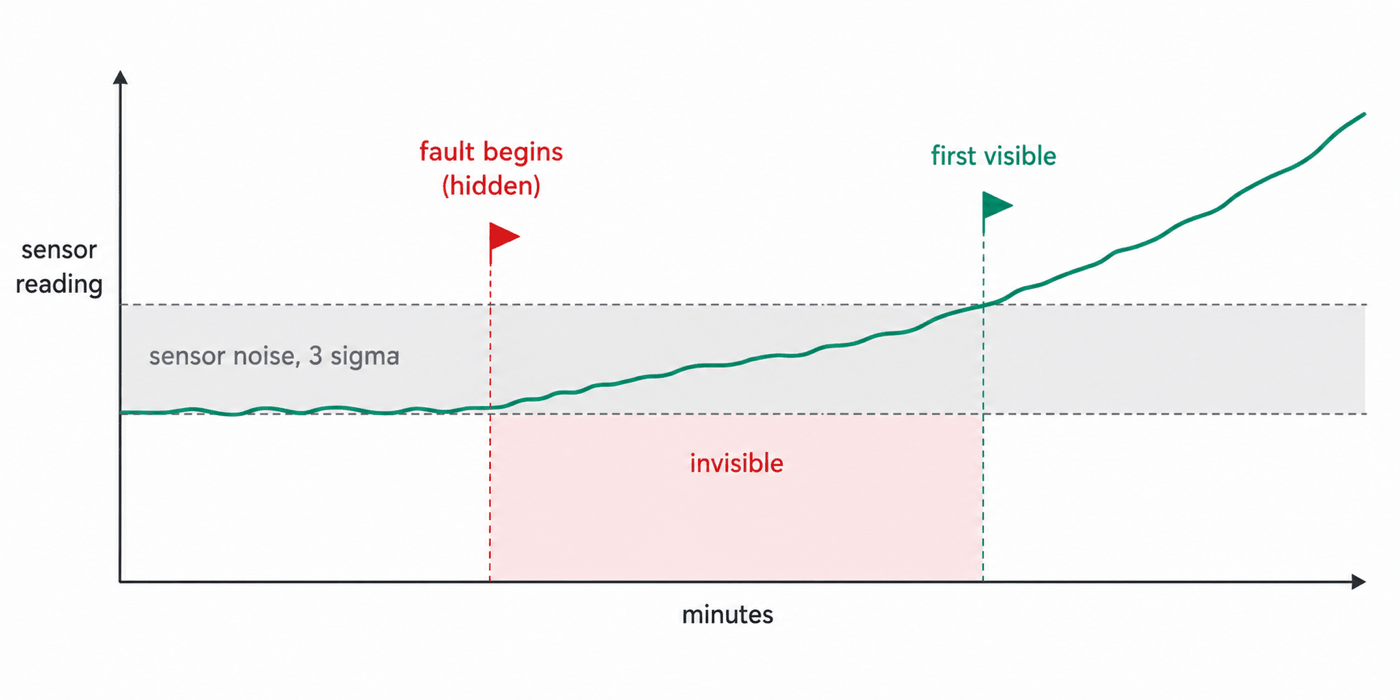

(The coverage metrics that turn confidence into an autonomy number stay in
the repo's `harness/score.py`.)

In [4]:
"""Mechanical scoring: the oracle side of the measuring station.

The station's score is defined ONCE, here. Evaluation reports it and, later,
GRPO uses it verbatim as the reward. No separate reward engineering.

Reward (gated so partial credit cannot be farmed without the diagnosis):
  0.1  schema followed (parseable, on-menu answer)
  0.6  fault correct                     -- the verifiable core
  0.2  discriminating check chosen       -- gated on fault correct
  0.1  onset within window               -- gated on fault correct

Onset is scored against the first OBSERVABLE minute (detectable_onset_min:
first noiseless sensor deviation >= 3 sigma), with an asymmetric window
[d-5, d+25]: a reader cannot see a fault before its first symptom, and being
somewhat late is normal reading behavior. Scoring against the latent onset
would reward constant-guessing the middle of the range instead.
"""
import json
def extract_json(text):
    """Last balanced {...} block that parses as a dict with a "fault" key
    (falling back to the last valid object). Reasoning models think before
    answering, and thinking text can contain stray braces; the diagnosis is
    the final JSON object, not the first."""
    candidates = []
    start = text.find("{")
    while start != -1:
        depth = 0
        for i in range(start, len(text)):
            if text[i] == "{":
                depth += 1
            elif text[i] == "}":
                depth -= 1
                if depth == 0:
                    try:
                        obj = json.loads(text[start:i + 1])
                        if isinstance(obj, dict):
                            candidates.append(obj)
                        start = i  # continue scanning after this block
                    except json.JSONDecodeError:
                        pass
                    break
        start = text.find("{", start + 1)
    with_fault = [c for c in candidates if "fault" in c]
    if with_fault:
        return with_fault[-1]
    return candidates[-1] if candidates else None


def _conf(x):
    try:
        return max(0.0, min(1.0, float(x)))
    except (TypeError, ValueError):
        return None


def _onset_ok(pred_onset, truth):
    d = truth.get("detectable_onset_min")
    if d is None:  # no_fault or never-observable: no onset to name
        return truth["onset_min"] is None
    try:
        return d - 5 <= int(pred_onset) <= d + 25
    except (TypeError, ValueError):
        return False


def _assemble(parsed, escalated, fault_ok, check_ok, onset_ok, confidence):
    check_ok = check_ok and fault_ok   # gated
    onset_ok = onset_ok and fault_ok
    return {"parsed": parsed, "escalated": escalated, "fault_correct": fault_ok,
            "check_ok": check_ok, "onset_ok": onset_ok, "confidence": confidence,
            "reward": round(0.1 * parsed + 0.6 * fault_ok
                            + 0.2 * check_ok + 0.1 * onset_ok, 4)}


def score(pred, truth):
    """Structured (M1+) scoring. pred: parsed model JSON or None."""
    if pred is None:
        return _assemble(False, False, False, False, False, None)
    conf = _conf(pred.get("confidence"))
    fault = str(pred.get("fault", "")).strip().lower()
    if fault == "escalate":
        return _assemble(True, True, False, False, False, conf)
    fault_ok = fault == truth["fault"]
    check = str(pred.get("check", "")).strip().lower()
    check_ok = check in (c.lower() for c in truth["checks"]) if truth["checks"] \
        else fault_ok
    return _assemble(True, False, fault_ok, check_ok,
                     _onset_ok(pred.get("onset_min"), truth), conf)


### The model, locally

Tokenization goes through mistral-common (the official preprocessing path)
and the mlx model is driven at token level, which makes the tokens the model
sees here byte-identical to the ones the SFT cell below trains on. The JSON
contract the model must fill is the schema block in `build_messages`.

In [5]:
"""Model backends. The harness only ever sees generate(messages) -> text.

Two implementations on purpose: the measuring station must be model- and
backend-neutral. MLXBackend runs fully local (this repo's default). The
OpenAI-compatible backend points the same harness at a vLLM endpoint
on-prem or at Mistral's La Plateforme in the cloud, unchanged.

Note: we tokenize with mistral-common (the official preprocessing path)
and drive the mlx model at token level.
"""

import mlx.core as mx
from mistral_common.protocol.instruct.messages import SystemMessage, UserMessage
from mistral_common.protocol.instruct.request import ChatCompletionRequest
from mistral_common.tokens.tokenizers.mistral import MistralTokenizer
from mlx_lm import load
from mlx_lm.generate import generate_step
from mlx_lm.sample_utils import make_sampler

TOKENIZER_REPO = "mistralai/Ministral-3-3B-Instruct-2512"
MODEL_REPO = "mlx-community/Ministral-3-3B-Instruct-2512-4bit"


def _to_mistral_messages(messages):
    out = []
    for m in messages:
        cls = SystemMessage if m["role"] == "system" else UserMessage
        out.append(cls(content=m["content"]))
    return out


class MLXBackend:
    def __init__(self, model_repo=MODEL_REPO, tokenizer_repo=TOKENIZER_REPO,
                 adapter_path=None):
        self.model, _ = load(model_repo, adapter_path=adapter_path)
        self.tok = MistralTokenizer.from_hf_hub(tokenizer_repo)
        self.eos = self.tok.instruct_tokenizer.tokenizer.eos_id

    def generate(self, messages, max_tokens=300, temperature=0.0):
        req = ChatCompletionRequest(messages=_to_mistral_messages(messages))
        ids = self.tok.encode_chat_completion(req).tokens
        sampler = make_sampler(temp=temperature)
        out = []
        for token, _ in generate_step(mx.array(ids), self.model, sampler=sampler,
                                      max_tokens=max_tokens):
            t = int(token)
            if t == self.eos:
                break
            out.append(t)
            if len(out) >= max_tokens:
                break
        return self.tok.decode(out)


"""Prompt construction for each experimental condition.

M0 naive: the log and a plain question. No schema, no menus. This is what
"just point a model at it" looks like.

M1 harness: fixed output schema, the fault vocabulary, the check menu, and
an explicit escalation option. Same model, same log; only the contract
around it changes.

M2 = M1 + k excavated knowledge cards.
"""
import json


def fault_menu(domain):
    return sorted(domain["faults"].keys()) + ["no_fault"]


def build_messages(domain, log, mode="harness", cards=None):
    if mode == "naive":
        return [{
            "role": "user",
            "content": (
                "Here is a shift log from a small beverage bottling line.\n\n"
                f"{log}\n\n"
                "Is anything wrong with the line? If so, what is the most likely "
                "root cause and around what minute did it start? If everything "
                "looks normal, say so. Reply briefly and end with one line: "
                "confidence: <0.0-1.0>"
            ),
        }]

    schema = {
        "fault": "one of the fault list, or 'no_fault', or 'escalate'",
        "component": "the physical part you blame",
        "onset_min": "integer, minute the problem started",
        "confidence": "0.0 to 1.0, your honest confidence",
        "check": "exactly one item from the check menu: the single test that best confirms your diagnosis",
        "evidence": "1-3 quotes from the log, each under 12 words",
    }
    system = (
        "You are the diagnosis assistant for LINE-1, a small beverage bottling line: "
        "tank -> pump -> filter -> heater (pasteurization) -> 4 filler nozzles -> conveyor.\n"
        "Read the shift log and identify the most likely root cause.\n\n"
        f"Fault list: {json.dumps(fault_menu(domain))}\n"
        f"Check menu: {json.dumps(domain['check_menu'])}\n\n"
        "If the evidence is insufficient or ambiguous, set fault to 'escalate' "
        "(a senior engineer will take over; this is the correct move when unsure).\n"
        f"Respond with a single JSON object, no other text: {json.dumps(schema)}"
    )
    user = f"Shift log:\n\n{log}"
    if cards:
        user += "\n\nSenior engineer notes:\n" + "\n".join(f"- {c}" for c in cards)
    return [{"role": "system", "content": system}, {"role": "user", "content": user}]


/Users/mottori/minifab/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### A live mini-run

Twelve fresh episodes, the same model twice: bare (k=0) and with eight
knowledge cards in context (k=8): short senior-engineer facts about the line,
written by reading where the naive model actually fails, injected as plain
context. The first call downloads the
4-bit model (about 2 GB); the twelve episodes then take a few minutes per
condition. Demo scale, so expect noisy numbers; the full study below runs 54
episodes per condition.

In [6]:
CARDS = [
  "If all four nozzles underfill by roughly the same amount, the problem is upstream of the nozzles (filter, pump, or valve). A single clogged nozzle shows one nozzle low and the others normal.",
  "Pressure brackets the filter: clogging raises the pressure before the filter and lowers it after. If both pressures fall together, suspect the pump or an upstream leak, not the filter.",
  "Trust the handheld thermometer over the panel. If they disagree, the temperature sensor is drifting, and because the controller believes the panel, the real process is off target in the opposite direction.",
  "Heater power climbing while panel temperature stays on target means the controller is compensating for something: real heat loss from a degrading heater, or a lying sensor. The handheld cross-check separates the two.",
  "Rising pump current with rising vibration points at the pump bearing. Rising current with normal vibration points at increased load, usually a clogging filter.",
  "A step change that coincides with a recipe load or a shift change is usually configuration, not hardware. Check the loaded recipe before opening the machine.",
  "Fill volume tracks flow: a slow global fill drop alongside falling flow is hydraulic. Fill scatter with normal flow points at the filler or the conveyor.",
  "Overfilled bottles during conveyor speed dips mean bottles linger under the nozzles. Check belt tension before blaming the nozzles."
]

import random
FAULTS = sorted(DOMAIN["faults"]) + ["no_fault"]
episodes = []
rng = random.Random(7)
picks = rng.sample(FAULTS * 2, k=12)
for i, f in enumerate(picks):
    fault = None if f == "no_fault" else f
    ep = generate_episode(DOMAIN, fault, seed=5000 + i)
    episodes.append(ep)

be = MLXBackend()
for k in (0, 8):
    hits = esc = 0
    for ep in episodes:
        msgs = build_messages(DOMAIN, ep["log"], mode="harness",
                              cards=CARDS[:k] if k else None)
        raw = be.generate(msgs, max_tokens=450)
        s = score(extract_json(raw), ep["truth"])
        hits += s["fault_correct"]
        esc += s["escalated"]
    print(f"k={k}: {hits}/12 correct, {esc} escalated")

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 171897.70it/s]

k=0: 2/12 correct, 0 escalated


k=8: 4/12 correct, 0 escalated


### What knowledge buys: the exchange rate

The full study injects the first k cards on 54 held-out episodes:

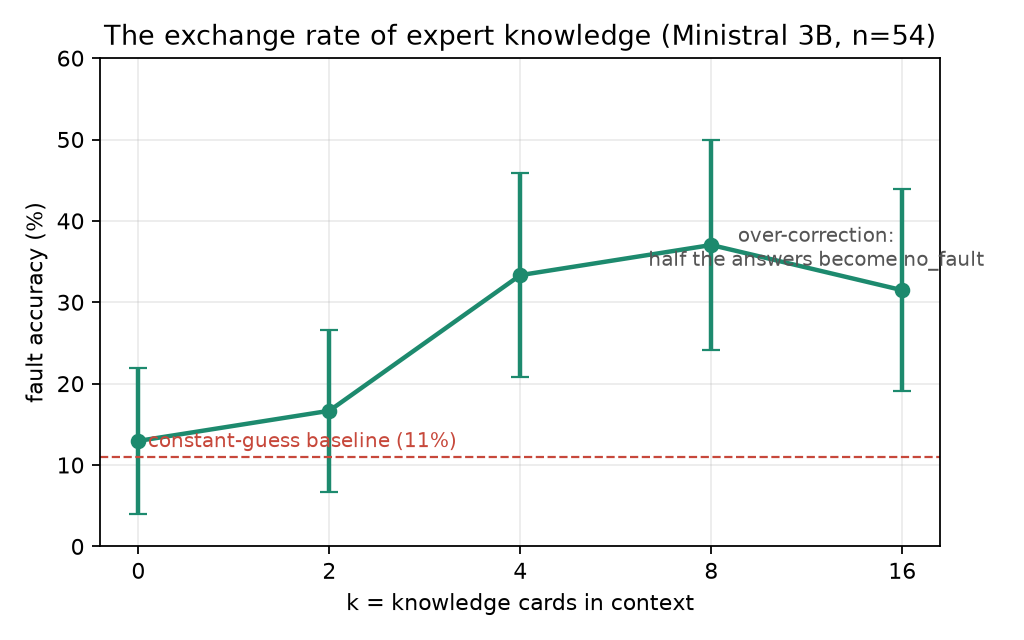

Three findings. The marginal utility of knowledge is lumpy: the two cards
that separate the trap pairs buy 16 points at once, while the first two
mostly remove wrong answers. The curve is not monotone: at k=16 the model
over-corrects and answers `no_fault` for half the caseload. And a boundary
is visible: cards fix classes where one explicit rule decides, while classes
needing multi-step causal reading stay at zero even with the right cards in
hand. In-context knowledge has a ceiling; past it, the knowledge has to move
into the weights. Throughout all of this the model never once escalates, and
its stated confidence sits at 0.95 almost everywhere.

### Judging the judge

Rubric LLM judges are the usual answer where no ground truth exists. The
station's rule: a judge earns reward duty only after its blind spots are
measured on the verifiable core. Tested on the model's own confidently wrong
answers (organic specimens, nothing manufactured; the judge is the same 3B):

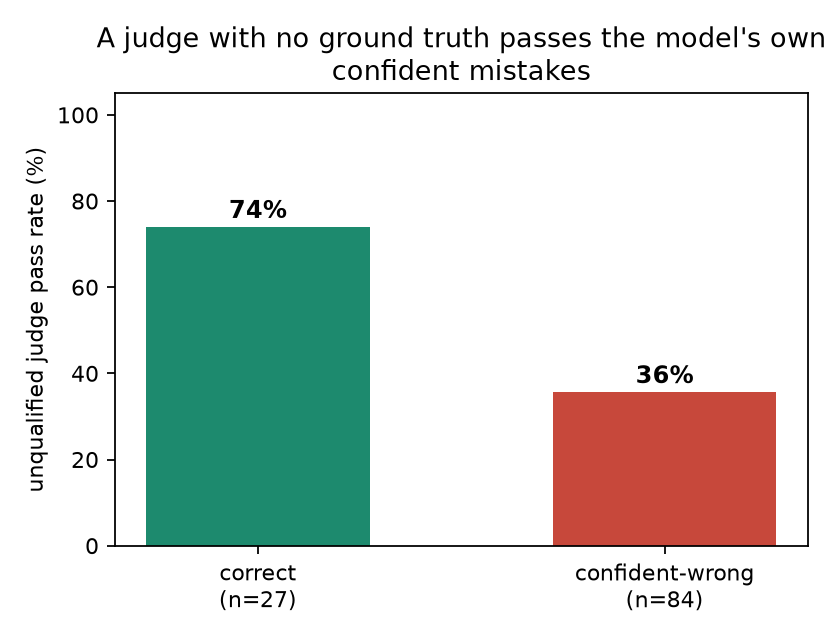

It passes 36% of the confident mistakes, rejects 26% of correct answers, and
its numeric scores (8.6 vs 8.9) cannot separate the two at all. Measured
against the oracle, this judge does not qualify to hand out reward, and the
measurement that disqualifies it is only possible because the verifiable core
exists. A stronger judge would blunt these numbers; what scales is the exam,
not the verdict.

### Fine-tuning on the station's own episodes

The station's episodes are already training data: same prompt contract, gold
answers completed by the oracle (onset as first visible minute, the fault's
discriminating check, two log lines as evidence). One deliberate hole:
`belt_slip` is held out of training entirely, so the requalification can
measure what tuning does not fix. Gold confidence is a flat 0.9, a known
limitation: calibration is not something SFT on gold labels can teach.

In [7]:
import re

def gold_evidence(ep):
    """1-2 log lines at/after the first observable minute."""
    d = ep["truth"]["detectable_onset_min"]
    if d is None:
        return []
    lines = [line for line in ep["log"].splitlines() if re.match(r"\[\d{3}m\]", line)]
    after = [line for line in lines if int(line[1:4]) >= d]
    return after[:2]


def gold_answer(ep):
    t = ep["truth"]
    if t["fault"] == "no_fault":
        # healthy line: the check slot just keeps the schema complete;
        # truth lists no discriminating check, so it can never earn credit
        return {"fault": "no_fault", "component": "none", "onset_min": None,
                "confidence": 0.9, "check": "review the loaded recipe settings",
                "evidence": []}
    return {"fault": t["fault"], "component": t["component"],
            "onset_min": t["detectable_onset_min"], "confidence": 0.9,
            "check": t["checks"][0], "evidence": gold_evidence(ep)}

HELDOUT = "belt_slip"
train_faults = [f for f in FAULTS if f != HELDOUT]
sft_rows = []
for i in range(640):
    f = train_faults[i % len(train_faults)]
    ep = generate_episode(DOMAIN, None if f == "no_fault" else f, seed=20000 + i)
    msgs = build_messages(DOMAIN, ep["log"], mode="harness")
    sft_rows.append({"messages": msgs + [
        {"role": "assistant", "content": json.dumps(gold_answer(ep))}]})
print(f"{len(sft_rows)} gold episodes; {HELDOUT} held out entirely")
print(sft_rows[0]["messages"][2]["content"][:180])

640 gold episodes; belt_slip held out entirely
{"fault": "filter_clog", "component": "filter", "onset_min": 53, "confidence": 0.9, "check": "compare pressure before vs after the filter", "evidence": ["[054m] pump 2.00 A | P.bef


The SFT loop is deliberately small. Tokenization is byte-identical to the
inference path above (same `encode_chat_completion`, same EOS), and the loss
is masked to the gold answer only; sequences run to ~2.8k tokens because the
logs are dense with numbers. LoRA rank 8 on the 4-bit model, one epoch, no
repetition. Flip the flag to reproduce (about four hours, ~6.5 GB peak).

In [8]:
import mlx.nn as nn

def encode_sample(tok, messages):
    """(system, user, assistant) -> token ids + prompt length.

    Prompt ids come from encode_chat_completion exactly as inference does;
    the assistant gold answer is appended as plain tokens plus EOS.
    """
    req = ChatCompletionRequest(messages=[
        SystemMessage(content=messages[0]["content"]),
        UserMessage(content=messages[1]["content"]),
    ])
    prompt_ids = tok.encode_chat_completion(req).tokens
    inner = tok.instruct_tokenizer.tokenizer
    answer_ids = inner.encode(messages[2]["content"], bos=False, eos=False)
    return prompt_ids + answer_ids + [inner.eos_id], len(prompt_ids)


def masked_loss(model, ids, prompt_len):
    logits = model(ids[None, :-1])
    targets = ids[None, 1:]
    ce = nn.losses.cross_entropy(logits, targets, reduction="none")
    mask = mx.arange(targets.shape[1])[None, :] >= (prompt_len - 1)
    return (ce * mask).sum() / mask.sum()

TRAIN = False  # one epoch over 608 episodes ~= 4 hours on an M-series Mac

if TRAIN:
    import mlx.optimizers as optim
    from mlx.utils import tree_flatten
    from mlx_lm.tuner.trainer import grad_checkpoint
    from mlx_lm.tuner.utils import linear_to_lora_layers

    LORA = {"rank": 8, "dropout": 0.0, "scale": 20.0}
    data = [encode_sample(be.tok, r["messages"]) for r in sft_rows]
    data = [(mx.array(ids), p) for ids, p in data if len(ids) <= 3072]
    model = be.model
    model.freeze()
    linear_to_lora_layers(model, 16, LORA)
    grad_checkpoint(model.layers[0])
    opt = optim.AdamW(learning_rate=1e-5)
    step = nn.value_and_grad(model, masked_loss)
    for it, (ids, plen) in enumerate(data, 1):
        loss, grads = step(model, ids, plen)
        opt.update(model, grads)
        mx.eval(model.parameters(), opt.state)
        if it % 50 == 0:
            print(f"{it}/{len(data)}  loss {loss.item():.3f}")
    mx.save_safetensors("sft_adapters.safetensors",
                        dict(tree_flatten(model.trainable_parameters())))

Requalification is then a diff, not a new review: the same station, the
same 54 episodes, before and after. SFT lands at **87%** (from 13%), fixing
exactly the multi-step classes the cards could not. The held-out `belt_slip`
stays at 0 of 6, misdiagnosed with confidence: training repaired what it saw
and nothing else, which is the requalification working, not failing.
Confidence comes out a flat 0.9 (the gold label, faithfully learned), so at a
95%-accuracy bar the share of the caseload that could close without a senior
engineer is still zero: cards moved accuracy, then weights moved it much
further, and the confidence channel has not moved at all.

### RL with the scorer as the reward

The entire reward engineering for GRPO is the function below: it parses the
completion and returns the station score, verbatim. It is registered as a
custom reward for [mlx-lm-lora](https://github.com/Goekdeniz-Guelmez/mlx-lm-lora)
(`@register_reward_function("station_score")` in the repo's
`harness/grpo_reward.py`) and run with:

```
python -m mlx_lm_lora.train --model mlx-community/Ministral-3-3B-Instruct-2512-4bit \
  --train --train-mode grpo --train-type lora --data datasets/grpo \
  --reward-functions-file harness/grpo_reward.py --reward-functions station_score \
  --group-size 4 --temperature 0.8 --max-completion-length 350 \
  --batch-size 1 --iters 60 --learning-rate 1e-5 --grad-checkpoint
```

In [9]:
def station_score(prompts=None, completions=None, answers=None, answer=None,
                  types=None, **_):
    gold = answers if answers is not None else answer
    return [float(score(extract_json(c), json.loads(g))["reward"])
            for c, g in zip(completions, gold)]

Two arms, and the interesting result was not the designed one.

**Cold start** (from the base model): 13% to 20%. Sampling groups of four
from a 13-percent policy, most groups score identically at the schema floor,
the group advantage is zero, and the optimizer starves. Outcome-only reward
works where the policy already sometimes succeeds.

**Warm start** (from the SFT policy): warm-starting required merging the LoRA
into the 4-bit weights and re-quantizing, and the result came out at 69%,
well below the 87% it started from. A control evaluation of the merged model
*before any GRPO* scores 70%: the packaging step, not the training, ate the
17 points, and it ate the finest distinctions first (five of six
`heater_degradation` episodes fall back to `no_fault`; the filter/pump trap
pair re-confuses). The station caught the regression as a diff between three
rows, against a deployment format rather than a model. The figure is that
diff, drawn:

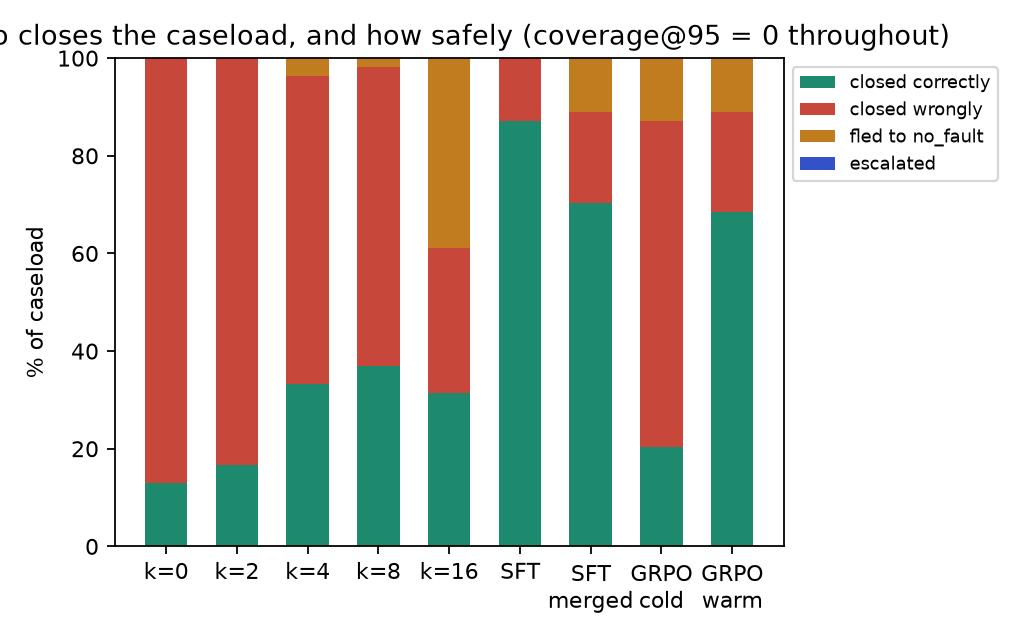

The caveat worth the price of this notebook if you deploy on MLX: **on a
quantized model, serve the adapter separately. Merging is not free.**

### The full ledger

Every condition of the full study, one table (54 held-out episodes each):

| condition | fault accuracy |
|---|---|
| naive prompt | 15% |
| structured harness, k=0 cards | 13% |
| k=4 cards | 33% |
| k=8 cards | 37% |
| k=16 cards | 31% |
| LoRA SFT, adapter on 4-bit | **87%** |
| the same SFT merged + re-quantized | 70% |
| GRPO, cold start | 20% |
| GRPO, warm start on the merged SFT | 69% |
| reasoning sibling, 2.5k thinking budget, hard cut | 15% |
| reasoning sibling, forced answer at the same 2.5k | 31% |
| reasoning sibling, 4k budget, zero cards | 37% |

The last three rows are one model, the reasoning variant of the same 3B,
under three closing policies. At a hard
2.5k cap, half its answers die inside the thinking block (zero schema
failures; pure budget exhaustion). Forcing the answer at the same cap doubles
accuracy, so half the measured deficit was the measurement's own cutoff. At
4k it matches the k=8 card configuration with zero cards, buying with
test-time tokens what cards buy in context, and it is the only configuration
that ever cracks the held-out `belt_slip` (1 of 6). Token budgets are part of
the measurement contract: numbers at different budgets are different
experiments.

One scope note: every number above is one point in the (model scale,
hardware) space, a 3B in 4-bit on a 16GB Mac mini, and the GRPO rows are
60-iteration probes. The loop's design is scale-free; the numbers are not.
The constraint is also the point: the entire loop, training included, runs
on hardware that fits inside a customer's wall, which is exactly the
deployment the smallest Ministral exists for.

### Where this goes

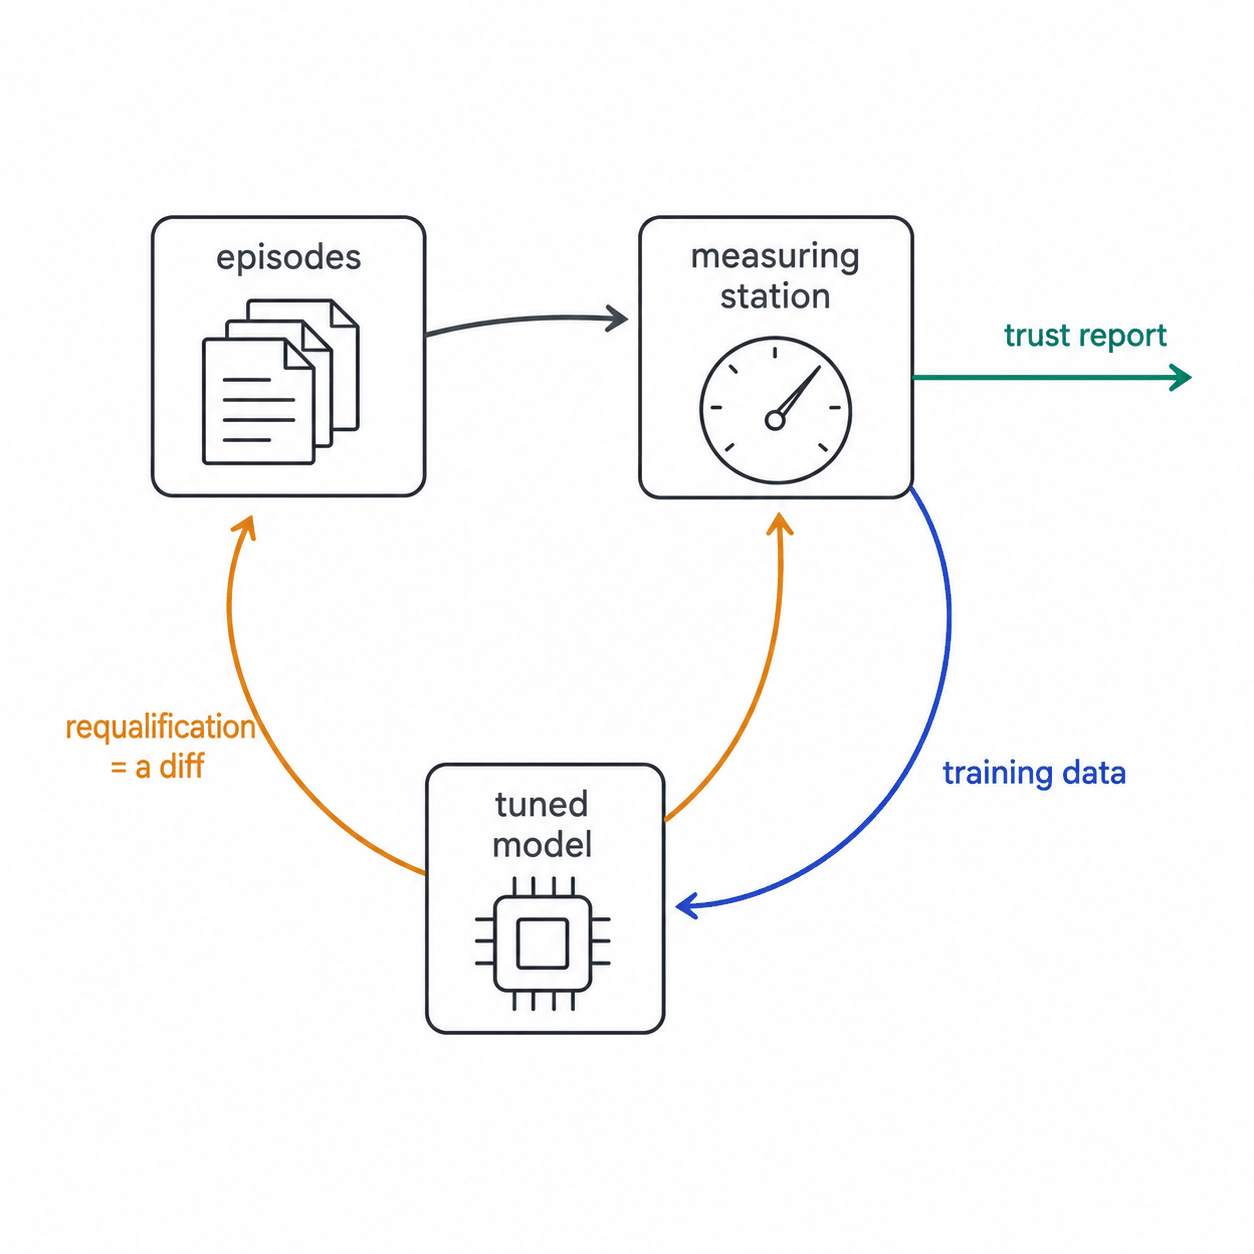

The loop is the point: episodes feed the station, the station emits a trust
report and training data at once, the tuned model walks back through the same
episodes, and requalification is a diff. Everything domain-specific fits in
one JSON, so a second production line is a new file.